In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_squared_error


In [ ]:
df=pd.read_csv("GlobalTemperatures.csv")
df['dt']=pd.to_datetime(df['dt'])
df.set_index('dt',inplace=True)

df=df[['LandAverageTemperature']]

df.dropna(inplace=True)

df.head()

,LandAverageTemperature
dt,
1750-01-01,3.034
1750-02-01,3.083
1750-03-01,5.626
1750-04-01,8.490
1750-05-01,11.573


In [ ]:
print(df.shape)
df.describe()

(3180, 1)


,LandAverageTemperature
count,3180.000000
mean,8.374731
std,4.381310
min,-2.080000
25%,4.312000
50%,8.610500
75%,12.548250
max,19.021000


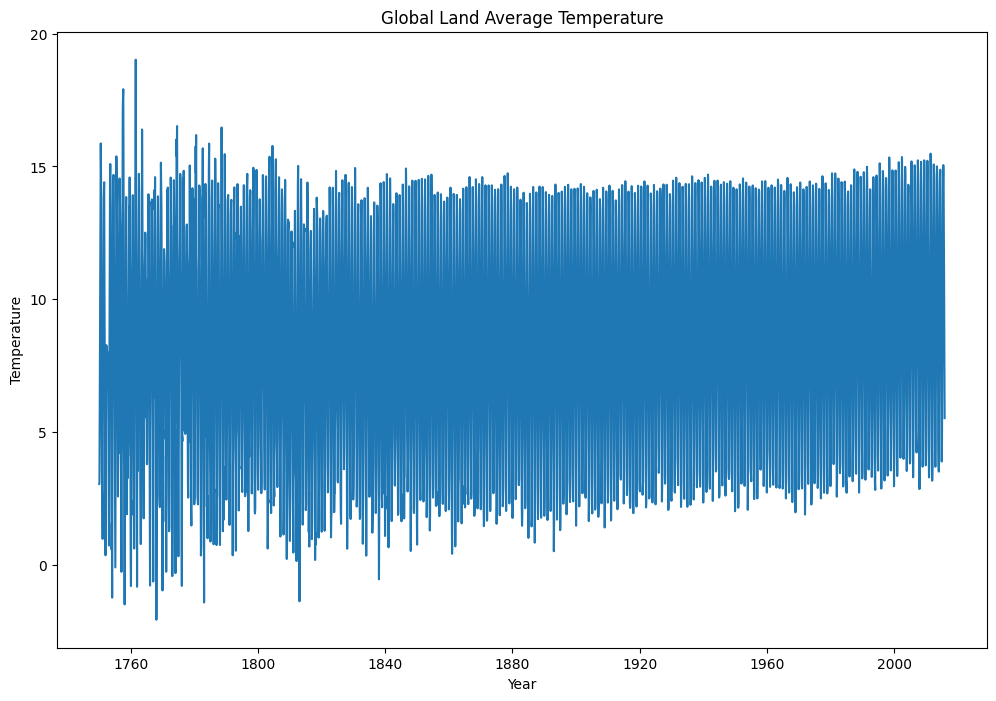

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(df)
plt.title("Global Land Average Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

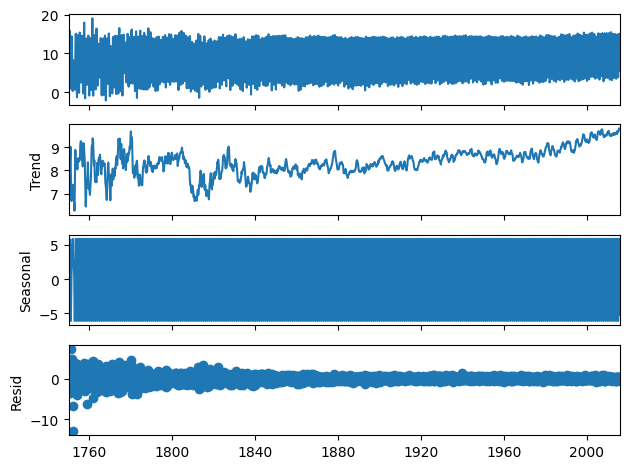

In [ ]:
decomp=seasonal_decompose(df, model="additive", period=12)
decomp.plot()
plt.show()

In [ ]:
#Stationarity check
result=adfuller(df['LandAverageTemperature'])

print("ADF Statistic: ", result[0])
print("p value: ", result[1])
print
for key, value in result[4].items():
  print("Critical value: ", key, value)

ADF Statistic:  -3.991677574351547
p value:  0.00145472238190585
Critical value:  1% -3.432427002601706
Critical value:  5% -2.8624576920765237
Critical value:  10% -2.5672585088743345


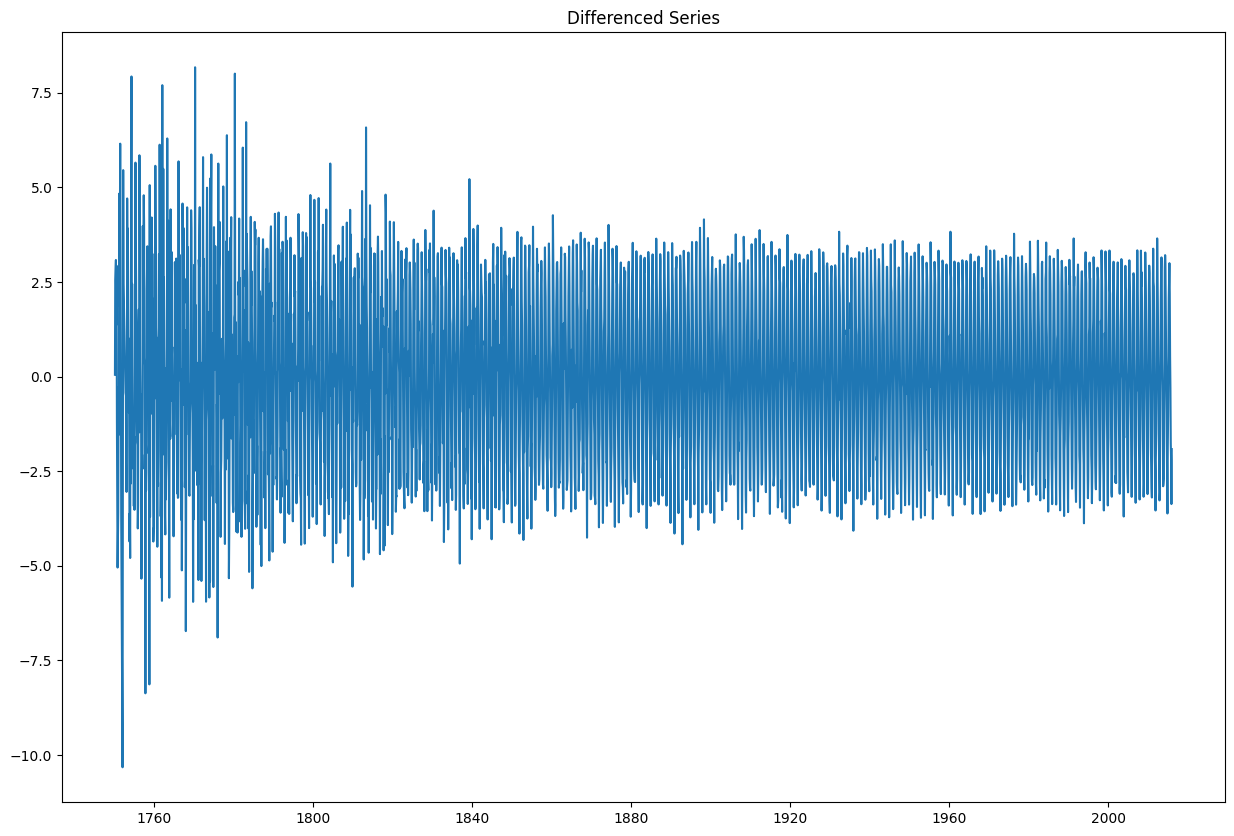

In [ ]:
df_diff=df.diff().dropna()
plt.figure(figsize=(15,10))
plt.plot(df_diff)
plt.title("Differenced Series")
plt.show()

In [ ]:
result=adfuller(df_diff['LandAverageTemperature'])
print("ADF Statistic: ", result[0])
print("p value: ", result[1])

ADF Statistic:  -16.360607806699477
p value:  2.8731009582994694e-29


In [ ]:
train_size=int((len(df))*0.8)
train=df[:train_size]
test=df[train_size:]
print(train.shape, test.shape)

(2544, 1) (636, 1)


In [ ]:
#Sarima model

sarima_model=SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_result=sarima_model.fit()
print(sarima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:             LandAverageTemperature   No. Observations:                 2544
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3298.644
Date:                            Sat, 07 Mar 2026   AIC                           6607.288
Time:                                    05:03:03   BIC                           6636.470
Sample:                                         0   HQIC                          6617.876
                                           - 2544                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3627      0.010     35.617      0.000       0.343       0.383
ma.L1         -0.9781      0.004   

In [ ]:
#Forecast

sarima_forecast=sarima_result.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
hw_model=ExponentialSmoothing(train, seasonal='add', seasonal_periods=12)
hw_result=hw_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
hw_forecast=hw_result.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


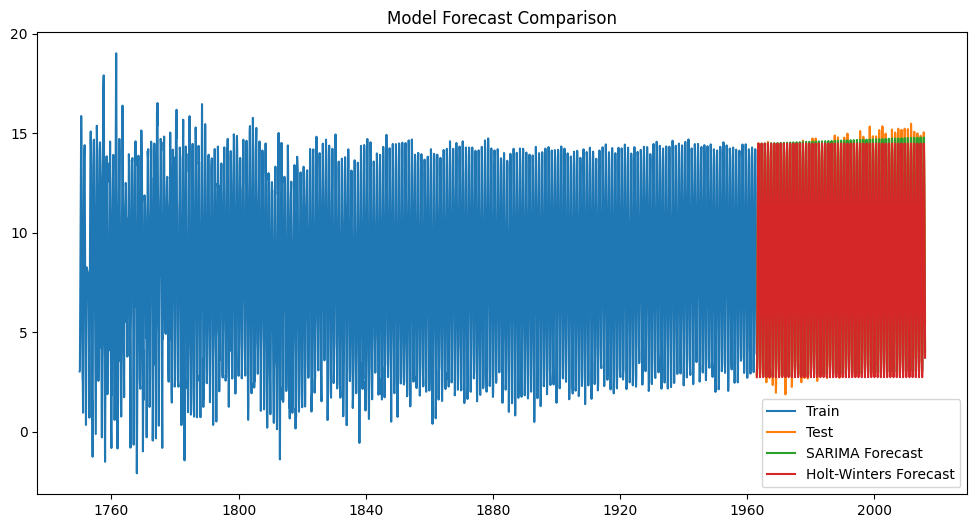

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Train")
plt.plot(test, label="Test")

plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")
plt.plot(test.index, hw_forecast, label="Holt-Winters Forecast")

plt.legend()
plt.title("Model Forecast Comparison")
plt.show()

In [ ]:
sarima_rmse=np.sqrt(mean_squared_error(test, sarima_forecast))
hw_rmse=np.sqrt(mean_squared_error(test, hw_forecast))

print("RMSE Results:")
print("SARIMA RMSE: ", sarima_rmse)
print("Holt-Winters RMSE: ", hw_rmse)

RMSE Results:
SARIMA RMSE:  0.46468515441193914
Holt-Winters RMSE:  0.5992489732585561


In [ ]:
results=pd.DataFrame({"Model":["SARIMA", "Holt-Winters"], "RMSE": [sarima_rmse, hw_rmse]})
results

,Model,RMSE
0,SARIMA,0.464685
1,Holt-Winters,0.599249


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/tmp/ipykernel_514/1872094935.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(df.index[-1], periods=120, freq='M'),


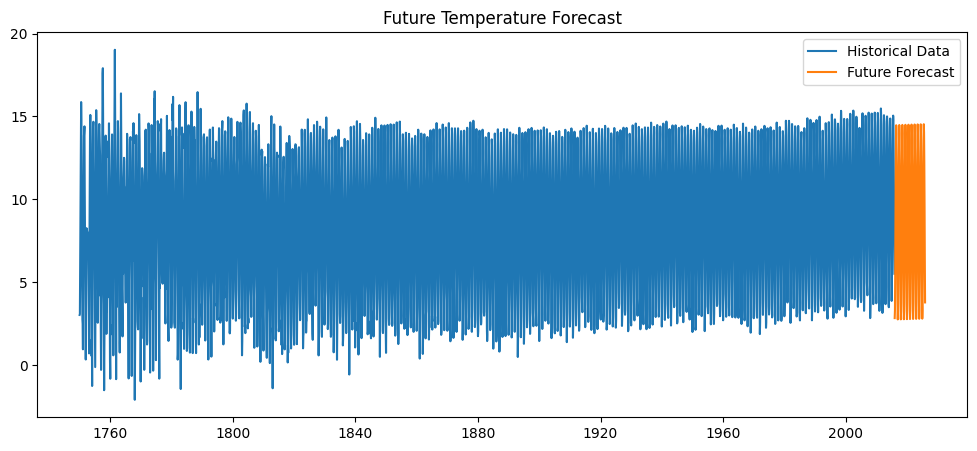

In [ ]:
future_forecast = sarima_result.forecast(steps=120)

plt.figure(figsize=(12,5))
plt.plot(df, label="Historical Data")
plt.plot(pd.date_range(df.index[-1], periods=120, freq='M'),
         future_forecast,
         label="Future Forecast")

plt.legend()
plt.title("Future Temperature Forecast")
plt.show()